# 🎵 Music Plagiarism Detection with Stem Separation

## Ідея

**Проблема:** Коли порівнюємо повний мікс пісень, ударні та бас "забивають" мелодію.

**Рішення:** Розділяємо пісню на компоненти (stems) і порівнюємо тільки мелодію!

```
Повний мікс              Після Stem Separation
─────────────            ──────────────────────
[vocals  ]               [vocals] ← окремо
[drums   ] разом         [drums]  ← окремо  
[bass    ]               [bass]   ← окремо
[melody  ]               [melody] ← ПОРІВНЮЄМО ЦЕ!
```

## 📦 Встановлення

In [23]:
# Demucs - найкращий stem separator
!pip install demucs torch torchaudio -q

# Інші залежності
!pip install librosa soundfile -q

print("✅ Installed!")

✅ Installed!


In [24]:
import numpy as np
import librosa
import subprocess
import tempfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready!")

✅ Imports ready!


## 📁 Шляхи до файлів

In [25]:
# ЗМІНІТЬ НА ВАШІ ФАЙЛИ!
QUERY_PATH = "/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/comparison/Vanilla Ice - Ice Ice Baby _Official Music Video_.wav"      # Можливий плагіат
REFERENCE_PATH = "/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/original/Queen - Under Pressure _Official Video_.wav"  # Оригінал
REFERENCE_PATH =  '/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/comparison/진주-난 괜찮아.wav'

# Перевірка
print(f"Query exists: {Path(QUERY_PATH).exists()}")
print(f"Reference exists: {Path(REFERENCE_PATH).exists()}")

Query exists: True
Reference exists: True


---
# Крок 1: Stem Separation

Розділяємо аудіо на 4 stems:
- **vocals** - вокал
- **drums** - ударні
- **bass** - бас
- **other** - все інше (мелодія, гітара, синтезатор)

In [26]:
def separate_stems(audio_path, output_dir=None):
    """
    Розділяє аудіо на stems використовуючи Demucs.
    
    Args:
        audio_path: шлях до аудіо файлу
        output_dir: куди зберегти (None = temp)
    
    Returns:
        dict: {'vocals': array, 'drums': array, 'bass': array, 'other': array}
    """
    audio_path = Path(audio_path)
    
    # Створюємо temp директорію
    if output_dir is None:
        output_dir = tempfile.mkdtemp()
    output_dir = Path(output_dir)
    
    print(f"Separating stems for: {audio_path.name}")
    
    # Запускаємо Demucs
    cmd = [
        'python', '-m', 'demucs',
        '-n', 'htdemucs',      # Модель (швидка і точна)
        '-o', str(output_dir), # Куди зберегти
        str(audio_path)
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"Error: {result.stderr}")
        return None
    
    # Завантажуємо stems
    stems_dir = output_dir / 'htdemucs' / audio_path.stem
    
    stems = {}
    for stem_name in ['vocals', 'drums', 'bass', 'other']:
        stem_path = stems_dir / f"{stem_name}.wav"
        if stem_path.exists():
            y, sr = librosa.load(stem_path, sr=22050, mono=True)
            stems[stem_name] = y
            print(f"  ✓ Loaded {stem_name}: {len(y)} samples")
    
    return stems

In [27]:
# Розділяємо обидва файли на stems
print("=" * 50)
print("QUERY:")
query_stems = separate_stems(QUERY_PATH)

print("\n" + "=" * 50)
print("REFERENCE:")
ref_stems = separate_stems(REFERENCE_PATH)

QUERY:
Separating stems for: Vanilla Ice - Ice Ice Baby _Official Music Video_.wav


  ✓ Loaded vocals: 925977 samples
  ✓ Loaded drums: 925977 samples
  ✓ Loaded bass: 925977 samples
  ✓ Loaded other: 925977 samples

REFERENCE:
Separating stems for: 진주-난 괜찮아.wav
  ✓ Loaded vocals: 738492 samples
  ✓ Loaded drums: 738492 samples
  ✓ Loaded bass: 738492 samples
  ✓ Loaded other: 738492 samples


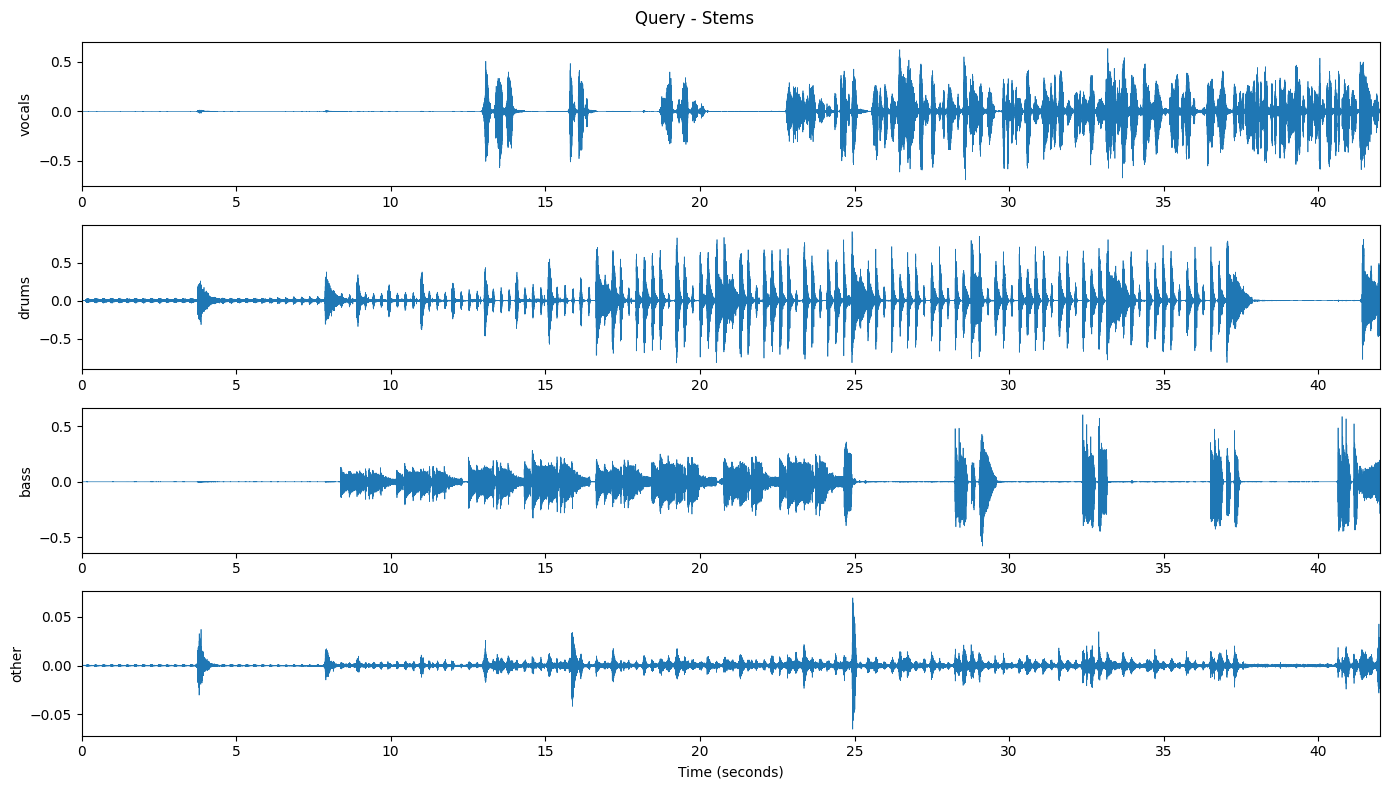

In [28]:
# Візуалізація stems
def plot_stems(stems, title="Stems"):
    fig, axes = plt.subplots(4, 1, figsize=(14, 8))
    
    for i, (name, audio) in enumerate(stems.items()):
        times = np.arange(len(audio)) / 22050
        axes[i].plot(times, audio, linewidth=0.5)
        axes[i].set_ylabel(name)
        axes[i].set_xlim(0, times[-1])
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if query_stems:
    plot_stems(query_stems, "Query - Stems")

---
# Крок 2: Екстракція Features (HPCP)

Для кожного stem екстрактуємо HPCP (Harmonic Pitch Class Profile).

HPCP показує **які ноти звучать** у кожен момент часу.

In [29]:
def extract_hpcp(audio, sr=22050):
    """
    Екстракція HPCP (chroma) features.
    
    Returns:
        array [12 x T]: 12 нот, T часових фреймів
    """
    # Нормалізуємо
    audio = librosa.util.normalize(audio)
    
    # HPCP (використовуємо chroma_cens - більш робастний)
    hpcp = librosa.feature.chroma_cens(y=audio, sr=sr)
    
    return hpcp


def beat_sync(features, audio, sr=22050):
    """
    Синхронізація по бітах (для інваріантності до темпу).
    """
    tempo, beats = librosa.beat.beat_track(y=audio, sr=sr)
    
    if len(beats) > 2:
        return librosa.util.sync(features, beats, aggregate=np.median)
    return features

In [30]:
# Екстрактуємо HPCP для кожного stem

def extract_stem_features(stems, use_beat_sync=True):
    """
    Екстракція HPCP для всіх stems.
    """
    features = {}
    
    for name, audio in stems.items():
        hpcp = extract_hpcp(audio)
        
        if use_beat_sync:
            hpcp = beat_sync(hpcp, audio)
        
        features[name] = hpcp
        print(f"  {name}: {hpcp.shape}")
    
    return features

print("Query features:")
query_features = extract_stem_features(query_stems)

print("\nReference features:")
ref_features = extract_stem_features(ref_stems)

Query features:
  vocals: (12, 76)
  drums: (12, 66)
  bass: (12, 66)
  other: (12, 82)

Reference features:
  vocals: (12, 64)
  drums: (12, 60)
  bass: (12, 41)
  other: (12, 84)


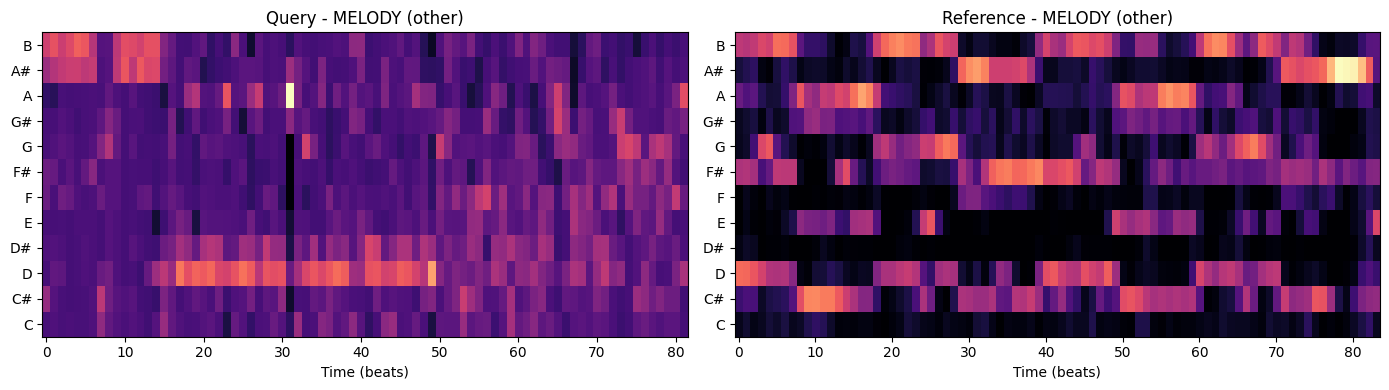

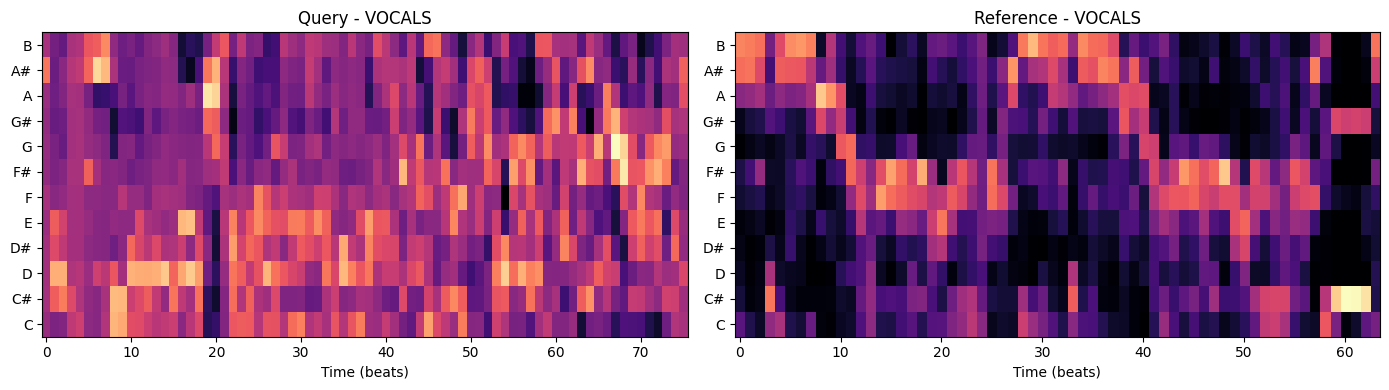

In [31]:
# Візуалізація HPCP для кожного stem
def plot_hpcp_comparison(query_feat, ref_feat, stem_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    axes[0].imshow(query_feat, aspect='auto', origin='lower', cmap='magma')
    axes[0].set_yticks(range(12))
    axes[0].set_yticklabels(notes)
    axes[0].set_title(f'Query - {stem_name}')
    axes[0].set_xlabel('Time (beats)')
    
    axes[1].imshow(ref_feat, aspect='auto', origin='lower', cmap='magma')
    axes[1].set_yticks(range(12))
    axes[1].set_yticklabels(notes)
    axes[1].set_title(f'Reference - {stem_name}')
    axes[1].set_xlabel('Time (beats)')
    
    plt.tight_layout()
    plt.show()

# Показуємо HPCP для мелодії (other stem)
plot_hpcp_comparison(query_features['other'], ref_features['other'], 'MELODY (other)')
plot_hpcp_comparison(query_features['vocals'], ref_features['vocals'], 'VOCALS')

---
# Крок 3: OTI (Optimal Transposition Index)

Знаходимо оптимальний зсув тональності (якщо плагіатор транспонував мелодію).

In [32]:
def compute_oti(hpcp1, hpcp2):
    """
    Знаходить оптимальний зсув тональності (0-11 півтонів).
    """
    # Глобальні профілі (усереднені по часу)
    g1 = np.mean(hpcp1, axis=1)  # [12]
    g2 = np.mean(hpcp2, axis=1)  # [12]
    
    # Нормалізуємо
    g1 = g1 / (np.linalg.norm(g1) + 1e-8)
    g2 = g2 / (np.linalg.norm(g2) + 1e-8)
    
    # Крос-кореляція через FFT
    corr = np.real(np.fft.ifft(np.fft.fft(g1) * np.conj(np.fft.fft(g2))))
    
    best_shift = int(np.argmax(corr))
    best_corr = corr[best_shift]
    
    return best_shift, best_corr


def apply_oti(hpcp, oti):
    """Застосовує зсув тональності"""
    if oti == 0:
        return hpcp
    return np.roll(hpcp, oti, axis=0)

In [33]:
# Обчислюємо OTI для мелодії
oti, oti_corr = compute_oti(query_features['other'], ref_features['other'])

print(f"OTI (melody): {oti} semitones")
print(f"Correlation: {oti_corr:.3f}")

if oti != 0:
    print(f"\n→ Мелодія транспонована на {oti} півтонів!")

OTI (melody): 1 semitones
Correlation: 0.896

→ Мелодія транспонована на 1 півтонів!


In [34]:
# Застосовуємо OTI до reference
ref_features_aligned = {}
for name, feat in ref_features.items():
    ref_features_aligned[name] = apply_oti(feat, oti)

print("✓ OTI applied to reference features")

✓ OTI applied to reference features


---
# Крок 4: Chunk-based порівняння

Ділимо на chunks і порівнюємо кожен chunk query з кожним chunk reference.

In [35]:
def segment_into_chunks(features, chunk_size=16, hop_size=8):
    """
    Ділить features на chunks.
    
    Args:
        features: [12 x T]
        chunk_size: розмір chunk в фреймах
        hop_size: крок між chunks
    
    Returns:
        list of chunks
    """
    n_frames = features.shape[1]
    chunks = []
    
    start = 0
    while start + chunk_size <= n_frames:
        chunk = features[:, start:start+chunk_size]
        chunks.append(chunk)
        start += hop_size
    
    # Останній chunk
    if start < n_frames and (n_frames - start) >= chunk_size // 2:
        chunks.append(features[:, start:])
    
    return chunks

In [36]:
def compare_two_chunks(chunk1, chunk2):
    """
    Порівнює два chunks.
    
    Returns:
        similarity: 0-1
    """
    # Вирівнюємо довжини
    len1, len2 = chunk1.shape[1], chunk2.shape[1]
    if len1 != len2:
        max_len = max(len1, len2)
        if len1 < max_len:
            chunk1 = np.pad(chunk1, ((0, 0), (0, max_len - len1)), mode='edge')
        if len2 < max_len:
            chunk2 = np.pad(chunk2, ((0, 0), (0, max_len - len2)), mode='edge')
    
    # DTW similarity
    try:
        D, _ = librosa.sequence.dtw(chunk1, chunk2, metric='cosine')
        dtw_dist = D[-1, -1] / (D.shape[0] + D.shape[1])
        dtw_sim = max(0, 1 - dtw_dist)
    except:
        dtw_sim = 0
    
    # Cosine similarity (global)
    g1 = np.mean(chunk1, axis=1)
    g2 = np.mean(chunk2, axis=1)
    cos_sim = np.dot(g1, g2) / (np.linalg.norm(g1) * np.linalg.norm(g2) + 1e-8)
    cos_sim = max(0, cos_sim)
    
    # Комбінуємо
    return 0.6 * dtw_sim + 0.4 * cos_sim

In [37]:
def chunk_based_comparison(query_hpcp, ref_hpcp, chunk_size=16, hop_size=8, threshold=0.55):
    """
    Повне chunk-based порівняння.
    
    Returns:
        dict з результатами
    """
    # Сегментуємо
    query_chunks = segment_into_chunks(query_hpcp, chunk_size, hop_size)
    ref_chunks = segment_into_chunks(ref_hpcp, chunk_size, hop_size)
    
    n_query = len(query_chunks)
    n_ref = len(ref_chunks)
    
    print(f"Query: {n_query} chunks")
    print(f"Reference: {n_ref} chunks")
    
    # Матриця схожості
    similarity_matrix = np.zeros((n_query, n_ref))
    
    for i in range(n_query):
        for j in range(n_ref):
            similarity_matrix[i, j] = compare_two_chunks(query_chunks[i], ref_chunks[j])
    
    # Знаходимо найкращий збіг для кожного query chunk
    best_matches = []
    for i in range(n_query):
        best_j = int(np.argmax(similarity_matrix[i, :]))
        best_sim = similarity_matrix[i, best_j]
        is_plag = best_sim >= threshold
        best_matches.append({
            'query_idx': i,
            'ref_idx': best_j,
            'similarity': best_sim,
            'is_plagiarism': is_plag
        })
    
    # Статистика
    n_plag = sum(1 for m in best_matches if m['is_plagiarism'])
    plag_ratio = n_plag / n_query
    
    sims = [m['similarity'] for m in best_matches]
    avg_sim = np.mean(sims)
    max_sim = np.max(sims)
    
    # Score
    score = 0.4 * avg_sim + 0.35 * plag_ratio + 0.25 * max_sim
    
    return {
        'matrix': similarity_matrix,
        'matches': best_matches,
        'n_plagiarized': n_plag,
        'n_total': n_query,
        'plag_ratio': plag_ratio,
        'avg_similarity': avg_sim,
        'max_similarity': max_sim,
        'score': score
    }

In [38]:
# Порівнюємо МЕЛОДІЮ (other stem)
print("=" * 50)
print("MELODY (other stem) comparison:")
print("=" * 50)

melody_result = chunk_based_comparison(
    query_features['other'],
    ref_features_aligned['other'],
    chunk_size=16,
    hop_size=8,
    threshold=0.55
)

print(f"\nPlagiarized chunks: {melody_result['n_plagiarized']}/{melody_result['n_total']}")
print(f"Plagiarism ratio: {melody_result['plag_ratio']*100:.1f}%")
print(f"Score: {melody_result['score']:.3f}")

MELODY (other stem) comparison:
Query: 10 chunks
Reference: 10 chunks

Plagiarized chunks: 10/10
Plagiarism ratio: 100.0%
Score: 0.913


In [39]:
# Порівнюємо ВОКАЛ
print("=" * 50)
print("VOCALS comparison:")
print("=" * 50)

vocals_result = chunk_based_comparison(
    query_features['vocals'],
    ref_features_aligned['vocals'],
    chunk_size=16,
    hop_size=8,
    threshold=0.55
)

print(f"\nPlagiarized chunks: {vocals_result['n_plagiarized']}/{vocals_result['n_total']}")
print(f"Plagiarism ratio: {vocals_result['plag_ratio']*100:.1f}%")
print(f"Score: {vocals_result['score']:.3f}")

VOCALS comparison:
Query: 9 chunks
Reference: 8 chunks

Plagiarized chunks: 9/9
Plagiarism ratio: 100.0%
Score: 0.946


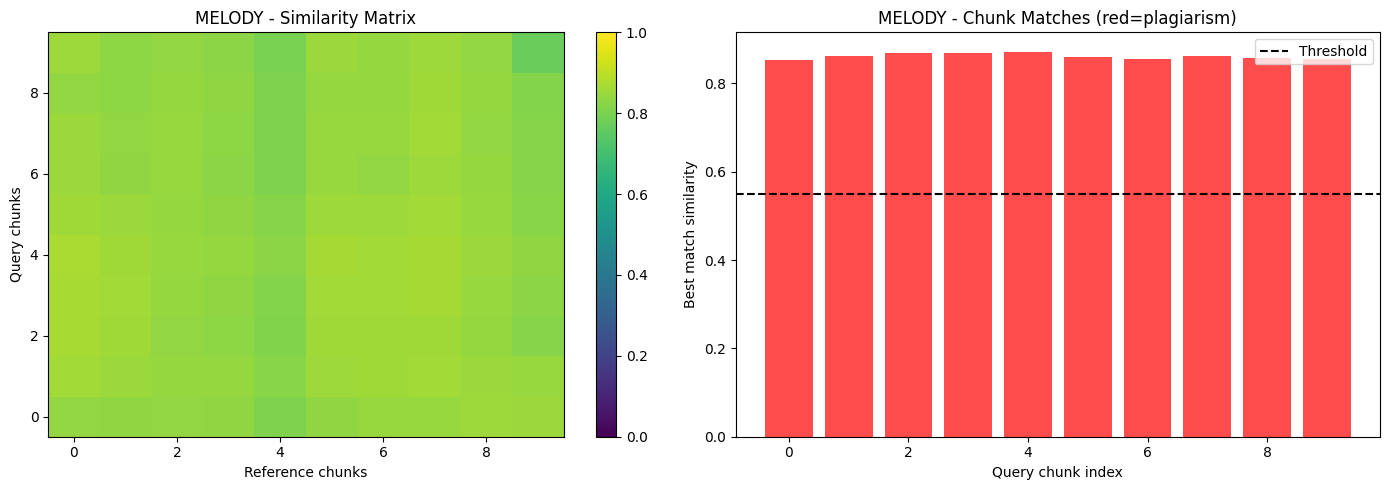

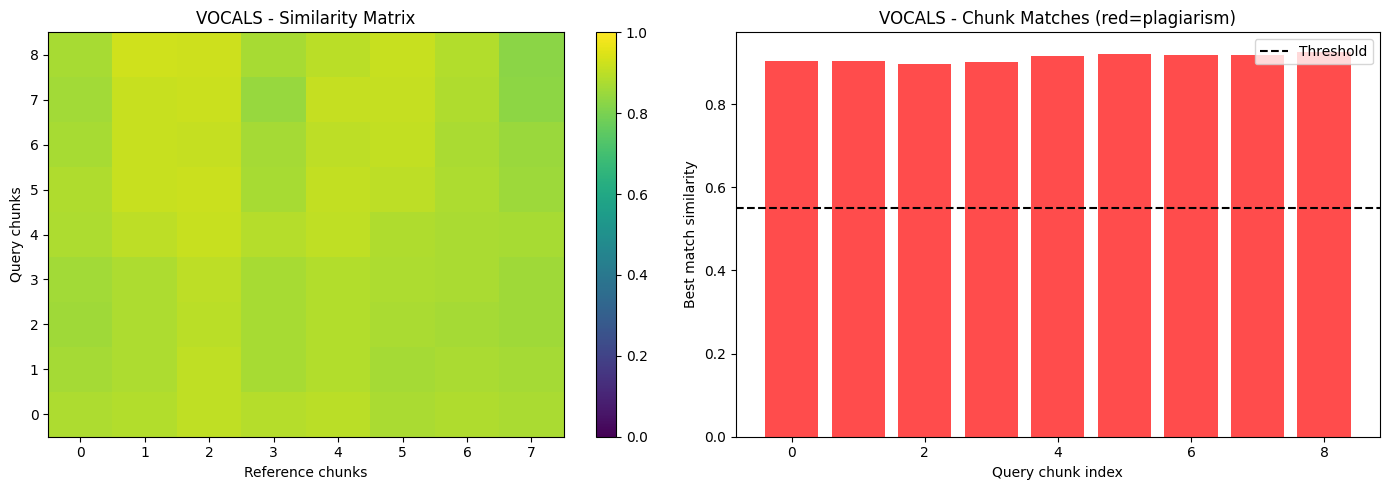

In [40]:
# Візуалізація матриці схожості
def plot_similarity_matrix(result, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Матриця
    im = axes[0].imshow(result['matrix'], aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
    axes[0].set_xlabel('Reference chunks')
    axes[0].set_ylabel('Query chunks')
    axes[0].set_title(f'{title} - Similarity Matrix')
    plt.colorbar(im, ax=axes[0])
    
    # Найкращі збіги
    sims = [m['similarity'] for m in result['matches']]
    colors = ['red' if m['is_plagiarism'] else 'blue' for m in result['matches']]
    
    axes[1].bar(range(len(sims)), sims, color=colors, alpha=0.7)
    axes[1].axhline(y=0.55, color='black', linestyle='--', label='Threshold')
    axes[1].set_xlabel('Query chunk index')
    axes[1].set_ylabel('Best match similarity')
    axes[1].set_title(f'{title} - Chunk Matches (red=plagiarism)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

plot_similarity_matrix(melody_result, 'MELODY')
plot_similarity_matrix(vocals_result, 'VOCALS')

---
# Крок 5: Фінальний результат

Комбінуємо результати від різних stems.

In [41]:
def calculate_final_score(melody_result, vocals_result):
    """
    Комбінує scores від різних stems.
    
    Ваги:
    - Мелодія (other): 60% - найважливіше для плагіату
    - Вокал: 40% - також важливий
    """
    # Ваги
    w_melody = 0.6
    w_vocals = 0.4
    
    final_score = w_melody * melody_result['score'] + w_vocals * vocals_result['score']
    
    # Якщо мелодія дуже схожа - довіряємо більше
    if melody_result['plag_ratio'] > 0.5:
        final_score = max(final_score, melody_result['score'] * 0.9)
    
    return final_score

In [42]:
# Обчислюємо фінальний score
final_score = calculate_final_score(melody_result, vocals_result)
threshold = 0.50

is_plagiarism = final_score >= threshold

# Звіт
print("\n" + "=" * 60)
print("📊 FINAL REPORT")
print("=" * 60)

print(f"\nQuery: {QUERY_PATH}")
print(f"Reference: {REFERENCE_PATH}")

print("\n" + "-" * 60)
print("STEM ANALYSIS:")
print("-" * 60)

print(f"\n🎸 MELODY (other stem):")
print(f"   Score: {melody_result['score']:.3f}")
print(f"   Plagiarized chunks: {melody_result['n_plagiarized']}/{melody_result['n_total']} ({melody_result['plag_ratio']*100:.1f}%)")

print(f"\n🎤 VOCALS:")
print(f"   Score: {vocals_result['score']:.3f}")
print(f"   Plagiarized chunks: {vocals_result['n_plagiarized']}/{vocals_result['n_total']} ({vocals_result['plag_ratio']*100:.1f}%)")

print(f"\n🎹 OTI: {oti} semitones")

print("\n" + "-" * 60)
print("FINAL DECISION:")
print("-" * 60)

print(f"\nFinal Score: {final_score:.3f}")
print(f"Threshold: {threshold}")

if is_plagiarism:
    print("\n🚨 PLAGIARISM DETECTED!")
else:
    print("\n✅ NO PLAGIARISM")

print("\n" + "=" * 60)


📊 FINAL REPORT

Query: /Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/comparison/Vanilla Ice - Ice Ice Baby _Official Music Video_.wav
Reference: /Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/comparison/진주-난 괜찮아.wav

------------------------------------------------------------
STEM ANALYSIS:
------------------------------------------------------------

🎸 MELODY (other stem):
   Score: 0.913
   Plagiarized chunks: 10/10 (100.0%)

🎤 VOCALS:
   Score: 0.946
   Plagiarized chunks: 9/9 (100.0%)

🎹 OTI: 1 semitones

------------------------------------------------------------
FINAL DECISION:
------------------------------------------------------------

Final Score: 0.926
Threshold: 0.5

🚨 PLAGIARISM DETECTED!



---
# 🎯 Все разом: проста функція

In [43]:
def detect_plagiarism_with_stems(query_path, ref_path, threshold=0.50):
    """
    Повний пайплайн детекції плагіату з stem separation.
    
    Args:
        query_path: шлях до можливого плагіату
        ref_path: шлях до оригіналу
        threshold: поріг для рішення
    
    Returns:
        dict з результатами
    """
    print("Step 1: Separating stems...")
    query_stems = separate_stems(query_path)
    ref_stems = separate_stems(ref_path)
    
    if not query_stems or not ref_stems:
        print("Error: Stem separation failed!")
        return None
    
    print("\nStep 2: Extracting features...")
    query_feat = {}
    ref_feat = {}
    
    for name in ['vocals', 'other']:
        q_hpcp = extract_hpcp(query_stems[name])
        q_hpcp = beat_sync(q_hpcp, query_stems[name])
        query_feat[name] = q_hpcp
        
        r_hpcp = extract_hpcp(ref_stems[name])
        r_hpcp = beat_sync(r_hpcp, ref_stems[name])
        ref_feat[name] = r_hpcp
    
    print("\nStep 3: Computing OTI...")
    oti, _ = compute_oti(query_feat['other'], ref_feat['other'])
    print(f"  OTI = {oti} semitones")
    
    # Apply OTI
    for name in ref_feat:
        ref_feat[name] = apply_oti(ref_feat[name], oti)
    
    print("\nStep 4: Chunk-based comparison...")
    melody_res = chunk_based_comparison(query_feat['other'], ref_feat['other'])
    vocals_res = chunk_based_comparison(query_feat['vocals'], ref_feat['vocals'])
    
    print("\nStep 5: Final score...")
    final_score = 0.6 * melody_res['score'] + 0.4 * vocals_res['score']
    
    if melody_res['plag_ratio'] > 0.5:
        final_score = max(final_score, melody_res['score'] * 0.9)
    
    is_plag = final_score >= threshold
    
    result = {
        'final_score': final_score,
        'is_plagiarism': is_plag,
        'melody_score': melody_res['score'],
        'melody_plag_ratio': melody_res['plag_ratio'],
        'vocals_score': vocals_res['score'],
        'vocals_plag_ratio': vocals_res['plag_ratio'],
        'oti': oti
    }
    
    # Print result
    print("\n" + "=" * 50)
    if is_plag:
        print("🚨 PLAGIARISM DETECTED!")
    else:
        print("✅ NO PLAGIARISM")
    print(f"Score: {final_score:.3f}")
    print(f"Melody: {melody_res['plag_ratio']*100:.1f}% similar")
    print(f"Vocals: {vocals_res['plag_ratio']*100:.1f}% similar")
    print("=" * 50)
    
    return result

In [44]:
# Використання
result = detect_plagiarism_with_stems(QUERY_PATH, REFERENCE_PATH)

Step 1: Separating stems...
Separating stems for: Vanilla Ice - Ice Ice Baby _Official Music Video_.wav
  ✓ Loaded vocals: 925977 samples
  ✓ Loaded drums: 925977 samples
  ✓ Loaded bass: 925977 samples
  ✓ Loaded other: 925977 samples
Separating stems for: 진주-난 괜찮아.wav
  ✓ Loaded vocals: 738492 samples
  ✓ Loaded drums: 738492 samples
  ✓ Loaded bass: 738492 samples
  ✓ Loaded other: 738492 samples

Step 2: Extracting features...

Step 3: Computing OTI...
  OTI = 8 semitones

Step 4: Chunk-based comparison...
Query: 9 chunks
Reference: 10 chunks
Query: 9 chunks
Reference: 8 chunks

Step 5: Final score...

🚨 PLAGIARISM DETECTED!
Score: 0.931
Melody: 100.0% similar
Vocals: 100.0% similar


---
# 💡 Підсумок

## Як працює пайплайн:

```
1. STEM SEPARATION (Demucs)
   Audio → [vocals] [drums] [bass] [other/melody]

2. FEATURE EXTRACTION
   vocals → HPCP → beat sync → [12 × N beats]
   melody → HPCP → beat sync → [12 × N beats]

3. OTI ALIGNMENT
   Знаходимо зсув тональності і вирівнюємо

4. CHUNK COMPARISON
   Ділимо на chunks → порівнюємо кожен з кожним → матриця схожості

5. FINAL SCORE
   60% melody + 40% vocals → рішення
```

## Переваги stem separation:

| Без stems | Зі stems |
|-----------|----------|
| Drums/bass забивають мелодію | Чиста мелодія |
| Шум в chroma | Чіткий сигнал |
| False positives від ритму | Тільки гармонія |
| Не знаємо ЩО схоже | Знаємо: vocals чи melody |